# limpieza

In [1]:
import polars as pl
import matplotlib.pyplot as plt

In [2]:
df = pl.read_parquet("data/raw/tomtom_move_reports/segments_1_to_31_aug_2024.parquet")

In [3]:
df.estimated_size('gb')

11.276446169242263

In [4]:
df.tail(3)

date,station_id,station_name,segment_id,new_segment_id,frc,street_name,distance_m,time_set_id,hour_start,hour_end,harmonic_avg_speed,median_speed,avg_speed,std_speed,travel_time_std,sample_size,normalized_sample_size,avg_travel_time,median_travel_time,travel_time_ratio,speed_percentiles,geometry_wkt
str,i64,str,i64,str,i64,str,f64,i64,i64,i64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,list[i64],str
"""2024-08-31""",2,"""NORTE""",14840013639640,"""fff1bf1d-0d5d-4af5-bbc8-101508…",7,null,153.51,23,21,22,0.0,0.0,0.0,null,null,0,0.0,0.0,0.0,0.0,"[0, 0, … 0]","""LINESTRING (-100.34139 25.7849…"
"""2024-08-31""",2,"""NORTE""",14840013639640,"""fff1bf1d-0d5d-4af5-bbc8-101508…",7,null,153.51,24,22,23,0.0,0.0,0.0,null,null,0,0.0,0.0,0.0,0.0,"[0, 0, … 0]","""LINESTRING (-100.34139 25.7849…"
"""2024-08-31""",2,"""NORTE""",14840013639640,"""fff1bf1d-0d5d-4af5-bbc8-101508…",7,null,153.51,25,23,24,0.0,0.0,0.0,null,null,0,0.0,0.0,0.0,0.0,"[0, 0, … 0]","""LINESTRING (-100.34139 25.7849…"


In [5]:
df.shape

(26999016, 23)

In [6]:
df.columns

['date',
 'station_id',
 'station_name',
 'segment_id',
 'new_segment_id',
 'frc',
 'street_name',
 'distance_m',
 'time_set_id',
 'hour_start',
 'hour_end',
 'harmonic_avg_speed',
 'median_speed',
 'avg_speed',
 'std_speed',
 'travel_time_std',
 'sample_size',
 'normalized_sample_size',
 'avg_travel_time',
 'median_travel_time',
 'travel_time_ratio',
 'speed_percentiles',
 'geometry_wkt']

In [7]:
df = df.drop('new_segment_id', 'geometry_wkt', 'std_speed', 'hour_end', 'time_set_id', 'travel_time_std', 'station_name', 'harmonic_avg_speed', 'avg_travel_time', 'travel_time_ratio', 'street_name', 'median_speed', 'normalized_sample_size', 'median_travel_time')

In [8]:
df.shape

(26999016, 9)

In [9]:
df.columns

['date',
 'station_id',
 'segment_id',
 'frc',
 'distance_m',
 'hour_start',
 'avg_speed',
 'sample_size',
 'speed_percentiles']

In [10]:
df.estimated_size('gb')

5.812542632222176

In [11]:
# quitar columnas son datos, es decir que en donde el sample_size sea 0

df = df.filter(pl.col('sample_size') > 0)

# generar indice

In [12]:
df

date,station_id,segment_id,frc,distance_m,hour_start,avg_speed,sample_size,speed_percentiles
str,i64,i64,i64,f64,i64,f64,i64,list[i64]
"""2024-08-01""",0,-14840000675661,5,82.01,0,24.3,9,"[16, 16, … 29]"
"""2024-08-01""",0,-14840000675661,5,82.01,1,28.6,10,"[19, 19, … 44]"
"""2024-08-01""",0,-14840000675661,5,82.01,2,29.3,8,"[13, 13, … 47]"
"""2024-08-01""",0,-14840000675661,5,82.01,3,9.4,1,"[9, 9, … 9]"
"""2024-08-01""",0,-14840000675661,5,82.01,4,18.7,3,"[16, 16, … 23]"
…,…,…,…,…,…,…,…,…
"""2024-08-31""",2,14840008820265,7,86.15,19,16.9,17,"[4, 4, … 40]"
"""2024-08-31""",2,14840008820265,7,86.15,20,19.7,14,"[4, 6, … 34]"
"""2024-08-31""",2,14840008820265,7,86.15,21,24.0,14,"[5, 6, … 81]"


In [13]:
# Calculo de el indice de congestión

longitud_coche = 4.5  # metros
espacio_entre_coches = 1.5  # metros
espacio_total_por_coche = longitud_coche + espacio_entre_coches  # metros

# Por cada segmento, se tiene que hacer:
# 1: calcular la velocidad maxima por segmento: para esto se toma el ultimo percentil de al columna speed_percentiles
# 2: calcular la densidad maxima de coches por segmento: distancia del segmento / espacio_total_por_coche
# 3: calcular la densidad actual de coches por segmento: densitdad máxima * (1- (velodidad actual / velocidad máxima))
# 4: calcular la cantidad de carriles: usar el frc: (0:4, 1:3, 2:3, 3:2, 4:2, 5:1, 6:1, 7:1)
# 5: guardar el indice de congestión en una nueva columna
# 6 dividir el máximo de congestion entre cada valor para tener un índice entre 0 y 1

# aclaración: que cada vez que se calcula una nueva fila que se sobreescribe la anterior, para que no se guarden todos los datos y no saturar la memoria.

In [14]:
# Implementación del cálculo del índice de congestión (CORREGIDA para Series de Polars)
import ast

# Función para extraer el último percentil, manejando Series de Polars
def extract_last_percentile(x):
    """
    Extrae el último valor de speed_percentiles.
    Maneja: Series de Polars, listas, tuplas, strings parseables, int/float.
    """
    if x is None:
        return None
    
    # Si es una Series de Polars, extraer el elemento (debería ser una lista)
    if hasattr(x, '__class__') and x.__class__.__name__ == 'Series':
        try:
            x = x[0]  # Extraer el primer (y único) elemento
        except Exception:
            return None
    
    # Ahora x debería ser una lista, tupla, número o string
    if isinstance(x, (list, tuple)):
        return float(x[-1]) if len(x) else None
    
    if isinstance(x, (int, float)):
        return float(x)
    
    # Si es string, intentar parsear
    if isinstance(x, str):
        try:
            v = ast.literal_eval(x)
            if isinstance(v, (list, tuple)) and v:
                return float(v[-1])
        except Exception:
            pass
        # Fallback: split por comas
        try:
            parts = [p.strip() for p in x.split(',') if p.strip()]
            return float(parts[-1]) if parts else None
        except Exception:
            return None
    
    return None

# Constantes
longitud_coche = 4.5  # metros
espacio_entre_coches = 1.5  # metros
espacio_total_por_coche = longitud_coche + espacio_entre_coches  # metros

# Mapeo FRC -> carriles
frc_to_lanes = {0:4, 1:3, 2:3, 3:2, 4:2, 5:1, 6:1, 7:1}

# Detectar columnas
length_col = 'distance_m' if 'distance_m' in df.columns else next((c for c in ['segment_length', 'length', 'segment_length_m', 'length_m', 'distance', 'segment_distance'] if c in df.columns), None)
speed_pct_col = 'speed_percentiles' if 'speed_percentiles' in df.columns else next((c for c in ['speed_percentile','speed_pct'] if c in df.columns), None)
current_speed_col = 'avg_speed' if 'avg_speed' in df.columns else next((c for c in ['speed','mean_speed','harmonic_avg_speed'] if c in df.columns), None)
frc_col = 'frc' if 'frc' in df.columns else next((c for c in ['functional_road_class'] if c in df.columns), None)

print('Detected columns:')
print(f'  length: {length_col}')
print(f'  speed_percentiles: {speed_pct_col}')
print(f'  current_speed: {current_speed_col}')
print(f'  frc: {frc_col}\n')

if length_col is None:
    raise ValueError('No se encontró una columna de longitud del segmento (esperada `distance_m`).')
if current_speed_col is None:
    raise ValueError('No se encontró columna de velocidad actual. Revisar nombres de columna.')

# Paso 1: Extraer max_speed del último valor de speed_percentiles
if speed_pct_col is not None:
    df = df.with_columns(
        pl.col(speed_pct_col).map_elements(extract_last_percentile, return_dtype=pl.Float64).alias('max_speed')
    )
else:
    if 'max_speed' in df.columns:
        df = df.with_columns(pl.col('max_speed').cast(pl.Float64))
    else:
        raise ValueError('No se encontró columna de percentiles de velocidad ni columna `max_speed`.')

# Paso 2: Calcular density_max (coches por metro)
df = df.with_columns(
    (pl.col(length_col).cast(pl.Float64) / espacio_total_por_coche).alias('density_max')
)

# Paso 3: Obtener velocidad actual
df = df.with_columns(
    pl.col(current_speed_col).cast(pl.Float64).alias('current_speed')
)

# Paso 4: Calcular número de carriles desde FRC
if frc_col is not None:
    df = df.with_columns(
        pl.col(frc_col).map_elements(lambda f: frc_to_lanes.get(int(f) if f is not None else -1, 1), return_dtype=pl.Int64).alias('lanes')
    )
else:
    df = df.with_columns(pl.lit(1).alias('lanes'))

# Paso 5: Calcular congestion_density = density_max * (1 - current_speed/max_speed)
df = df.with_columns(
    (pl.col('density_max') * (1 - (pl.col('current_speed') / pl.col('max_speed'))))
    .fill_null(0)
    .map_elements(lambda v: max(v, 0) if v is not None else 0, return_dtype=pl.Float64)
    .alias('congestion_density')
)

# Paso 6: Calcular congestion_raw = congestion_density * lanes
df = df.with_columns(
    (pl.col('congestion_density') * pl.col('lanes')).alias('congestion_raw')
)

# Paso 7: Normalizar congestion_index entre 0 y 1
max_raw = df.select(pl.col('congestion_raw').max()).to_series()[0]
if max_raw in (None, 0):
    df = df.with_columns(pl.lit(0.0).alias('congestion_index'))
else:
    df = df.with_columns(
        (pl.col('congestion_raw') / max_raw).alias('congestion_index')
    )

# Mostrar resultados
print('='*70)
print('RESULTADOS DEL CÁLCULO DE ÍNDICE DE CONGESTIÓN')
print('='*70)
print(f'Max raw congestion: {max_raw}')
print(f'Total filas procesadas: {df.height}')
print(f'\nMuestra de valores calculados:')
display_cols = ['segment_id', 'avg_speed', 'max_speed', 'distance_m', 'congestion_density', 'congestion_raw', 'congestion_index']
display_cols_exist = [c for c in display_cols if c in df.columns]
print(df.select(display_cols_exist).head(10))

Detected columns:
  length: distance_m
  speed_percentiles: speed_percentiles
  current_speed: avg_speed
  frc: frc

RESULTADOS DEL CÁLCULO DE ÍNDICE DE CONGESTIÓN
Max raw congestion: 28.237499999999997
Total filas procesadas: 11010280

Muestra de valores calculados:
shape: (10, 7)
┌───────────────┬───────────┬───────────┬────────────┬───────────────┬──────────────┬──────────────┐
│ segment_id    ┆ avg_speed ┆ max_speed ┆ distance_m ┆ congestion_de ┆ congestion_r ┆ congestion_i │
│ ---           ┆ ---       ┆ ---       ┆ ---        ┆ nsity         ┆ aw           ┆ ndex         │
│ i64           ┆ f64       ┆ f64       ┆ f64        ┆ ---           ┆ ---          ┆ ---          │
│               ┆           ┆           ┆            ┆ f64           ┆ f64          ┆ f64          │
╞═══════════════╪═══════════╪═══════════╪════════════╪═══════════════╪══════════════╪══════════════╡
│ -148400006756 ┆ 24.3      ┆ 16.0      ┆ 82.01      ┆ 0.0           ┆ 0.0          ┆ 0.0          │
│ 61      

(array([1.0928995e+07, 5.6988000e+04, 1.4137000e+04, 5.2760000e+03,
        2.3590000e+03, 1.1360000e+03, 5.6000000e+02, 3.7400000e+02,
        1.6900000e+02, 1.0200000e+02, 5.9000000e+01, 3.9000000e+01,
        2.2000000e+01, 1.9000000e+01, 1.6000000e+01, 9.0000000e+00,
        3.0000000e+00, 4.0000000e+00, 2.0000000e+00, 3.0000000e+00,
        2.0000000e+00, 1.0000000e+00, 2.0000000e+00, 2.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 1.0000000e+00]),
 array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 ,
        0.22, 0.24, 0.26, 0.28, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.

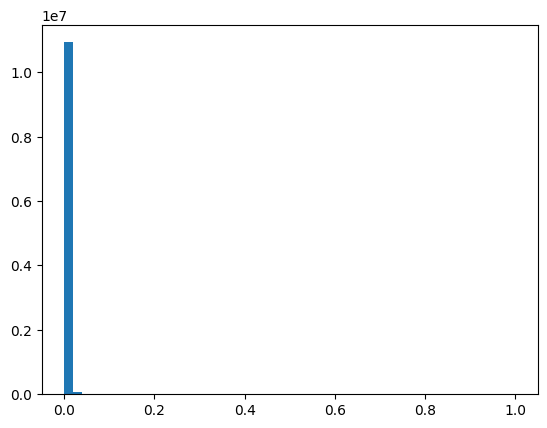

In [15]:
import matplotlib.pyplot as plt

# Visualización velocidad maxima, tomar unicamente el ultimo valor de la lista de speed_percentiles
plt.hist(df.select('congestion_index').to_series().drop_nulls(), bins=50)


In [16]:
df

date,station_id,segment_id,frc,distance_m,hour_start,avg_speed,sample_size,speed_percentiles,max_speed,density_max,current_speed,lanes,congestion_density,congestion_raw,congestion_index
str,i64,i64,i64,f64,i64,f64,i64,list[i64],f64,f64,f64,i64,f64,f64,f64
"""2024-08-01""",0,-14840000675661,5,82.01,0,24.3,9,"[16, 16, … 29]",16.0,13.668333,24.3,1,0.0,0.0,0.0
"""2024-08-01""",0,-14840000675661,5,82.01,1,28.6,10,"[19, 19, … 44]",19.0,13.668333,28.6,1,0.0,0.0,0.0
"""2024-08-01""",0,-14840000675661,5,82.01,2,29.3,8,"[13, 13, … 47]",13.0,13.668333,29.3,1,0.0,0.0,0.0
"""2024-08-01""",0,-14840000675661,5,82.01,3,9.4,1,"[9, 9, … 9]",9.0,13.668333,9.4,1,0.0,0.0,0.0
"""2024-08-01""",0,-14840000675661,5,82.01,4,18.7,3,"[16, 16, … 23]",16.0,13.668333,18.7,1,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2024-08-31""",2,14840008820265,7,86.15,19,16.9,17,"[4, 4, … 40]",4.0,14.358333,16.9,1,0.0,0.0,0.0
"""2024-08-31""",2,14840008820265,7,86.15,20,19.7,14,"[4, 6, … 34]",4.0,14.358333,19.7,1,0.0,0.0,0.0
"""2024-08-31""",2,14840008820265,7,86.15,21,24.0,14,"[5, 6, … 81]",5.0,14.358333,24.0,1,0.0,0.0,0.0


In [17]:
# Mantener solo las columnas esenciales
# df se reduce a: station_id, date, hour_start, segment_id, congestion_raw, congestion_index
df = df.select(['station_id', 'date', 'hour_start', 'segment_id', 'congestion_raw', 'congestion_index'])
print(f"df reducido a columnas esenciales: {df.shape}")
print(f"Columnas: {df.columns}")

df reducido a columnas esenciales: (11010280, 6)
Columnas: ['station_id', 'date', 'hour_start', 'segment_id', 'congestion_raw', 'congestion_index']


In [18]:
# Eliminar columnas no esenciales
# df = df.drop('frc', 'distance_m', 'sample_size', 'speed_percentiles', 'avg_speed', 'density_max', 'max_speed', 'current_speed', 'lanes', 'congestion_density', 'median_travel_time')
print(f"df después de eliminar columnas innecesarias: {df.shape}")

df después de eliminar columnas innecesarias: (11010280, 6)


In [19]:
print(f"Tamaño final de df: {df.estimated_size('gb')} GB")

Tamaño final de df: 0.5127061158418655 GB


In [20]:
print("="*80)
print("INFORMACIÓN FINAL DE DF")
print("="*80)
print(f"df final: {df.shape}")
print(f"Columnas: {df.columns}")
print(f"Tamaño: {df.estimated_size('gb')} GB")

INFORMACIÓN FINAL DE DF
df final: (11010280, 6)
Columnas: ['station_id', 'date', 'hour_start', 'segment_id', 'congestion_raw', 'congestion_index']
Tamaño: 0.5127061158418655 GB


In [21]:
# Generar 3 DataFrames, uno por estación, agregando por día y hora
# El df se subdivide progresivamente en DataFrames más pequeños por estación

print("\n" + "="*80)
print("AGREGACIÓN POR ESTACIÓN")
print("="*80 + "\n")

# Obtener estaciones únicas
stations = df.select('station_id').unique().sort('station_id').to_series().to_list()
print(f"Estaciones encontradas: {stations}")
print(f"Total estaciones: {len(stations)}\n")

# Crear 3 DataFrames, uno por estación (tomar las primeras 3)
for i, station in enumerate(stations[:3]):
    print(f"Procesando estación {i+1}/3: {station}")
    
    # Filtrar df para esta estación
    df_station = df.filter(pl.col('station_id') == station)
    
    # Agrupar por date y hour_start
    df_station_agg = df_station.group_by('date', 'hour_start').agg(
        pl.col('congestion_raw').sum().alias('congestion_raw_sum'),
        pl.col('congestion_raw').mean().alias('congestion_raw_mean'),
        pl.col('segment_id').count().alias('segment_count')
    ).sort('date', 'hour_start')
    
    print(f"  Tamaño: {df_station_agg.shape}")
    print(f"  Rango fechas: {df_station_agg['date'].min()} a {df_station_agg['date'].max()}")
    print(f"  Horas: {df_station_agg['hour_start'].min()} a {df_station_agg['hour_start'].max()}\n")
    
    # Guardar como variable global
    var_name = f"df_station_{i}"
    globals()[var_name] = df_station_agg
    print(f"  ✓ {var_name} creado\n")

print("="*80)
print("VARIABLES CREADAS: df_station_0, df_station_1, df_station_2")
print("="*80)


AGREGACIÓN POR ESTACIÓN

Estaciones encontradas: [0, 1, 2]
Total estaciones: 3

Procesando estación 1/3: 0
  Tamaño: (744, 5)
  Rango fechas: 2024-08-01 a 2024-08-31
  Horas: 0 a 23

  ✓ df_station_0 creado

Procesando estación 2/3: 1
  Tamaño: (744, 5)
  Rango fechas: 2024-08-01 a 2024-08-31
  Horas: 0 a 23

  ✓ df_station_1 creado

Procesando estación 3/3: 2
  Tamaño: (744, 5)
  Rango fechas: 2024-08-01 a 2024-08-31
  Horas: 0 a 23

  ✓ df_station_2 creado

VARIABLES CREADAS: df_station_0, df_station_1, df_station_2


In [22]:
df_station_0

date,hour_start,congestion_raw_sum,congestion_raw_mean,segment_count
str,i64,f64,f64,u32
"""2024-08-01""",0,114.562615,0.020109,5697
"""2024-08-01""",1,77.556966,0.0164,4729
"""2024-08-01""",2,70.581388,0.016533,4269
"""2024-08-01""",3,60.472245,0.016545,3655
"""2024-08-01""",4,68.723351,0.019191,3581
…,…,…,…,…
"""2024-08-31""",19,138.965502,0.018271,7606
"""2024-08-31""",20,112.094797,0.01491,7518
"""2024-08-31""",21,108.254938,0.014683,7373


In [23]:
df_station_1

date,hour_start,congestion_raw_sum,congestion_raw_mean,segment_count
str,i64,f64,f64,u32
"""2024-08-01""",0,72.97149,0.02133,3421
"""2024-08-01""",1,74.184452,0.024016,3089
"""2024-08-01""",2,49.134522,0.021974,2236
"""2024-08-01""",3,31.917566,0.015793,2021
"""2024-08-01""",4,48.002726,0.022421,2141
…,…,…,…,…
"""2024-08-31""",19,160.591303,0.030215,5315
"""2024-08-31""",20,157.075324,0.030131,5213
"""2024-08-31""",21,154.268696,0.028069,5496


In [24]:
df_station_2

date,hour_start,congestion_raw_sum,congestion_raw_mean,segment_count
str,i64,f64,f64,u32
"""2024-08-01""",0,85.316426,0.026645,3202
"""2024-08-01""",1,54.565433,0.020194,2702
"""2024-08-01""",2,53.759298,0.026947,1995
"""2024-08-01""",3,43.88591,0.022176,1979
"""2024-08-01""",4,35.649616,0.02202,1619
…,…,…,…,…
"""2024-08-31""",19,137.316199,0.027283,5033
"""2024-08-31""",20,144.964183,0.02828,5126
"""2024-08-31""",21,162.856797,0.032735,4975


# Comparación con las emisiones

In [27]:
import pandas as pd 

df_sima = pd.read_csv('main/data/interim/datos_limpios_2024.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'main/data/interim/datos_limpios_2024.csv'

In [ ]:
# Filtrar df_sima para quedarse solo con registros de agosto de 2024
df_sima['date'] = pd.to_datetime(df_sima['date'])
df_sima = df_sima[(df_sima['date'].dt.year == 2024) & (df_sima['date'].dt.month == 8)].copy()
print(f"Filas tras filtrar agosto 2024: {len(df_sima)}")
df_sima_centro = df_sima[df_sima['Zona'] == 'CENTRO'].copy()
print(f"Filas para estación CENTRO: {len(df_sima_centro)}")
df_sima_norte = df_sima[df_sima['Zona'] == 'NORTE'].copy()
print(f"Filas para estación NORTE: {len(df_sima_norte)}")
df_sima_sur = df_sima[df_sima['Zona'] == 'SURESTE'].copy()
print(f"Filas para estación SURESTE: {len(df_sima_sur)}")

Filas tras filtrar agosto 2024: 2232
Filas para estación CENTRO: 744
Filas para estación NORTE: 744
Filas para estación SURESTE: 744

Filas para estación CENTRO: 744
Filas para estación NORTE: 744
Filas para estación SURESTE: 744


In [ ]:
df_sima_norte

,date,CO,NO,NO2,NOX,O3,PM10,PM2.5,PRS,RAINF,RH,SO2,SR,TOUT,WSR,WDR,Zona
5110,2024-08-01 00:00:00,NaN,NaN,NaN,NaN,NaN,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NORTE
5111,2024-08-01 01:00:00,NaN,NaN,NaN,NaN,14.0,69.0,NaN,713.6,0.0,NaN,4.1,0.000,NaN,7.2,150.0,NORTE
5112,2024-08-01 02:00:00,NaN,NaN,NaN,NaN,13.0,76.0,NaN,713.5,0.0,NaN,3.5,0.000,NaN,2.2,118.0,NORTE
5113,2024-08-01 03:00:00,NaN,NaN,NaN,NaN,12.0,80.0,NaN,713.3,0.0,NaN,3.6,0.000,NaN,4.5,181.0,NORTE
5114,2024-08-01 04:00:00,NaN,NaN,NaN,NaN,11.0,83.0,NaN,713.2,0.0,NaN,3.7,0.000,NaN,4.9,209.0,NORTE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5849,2024-08-31 19:00:00,NaN,3.0,18.4,21.4,31.0,16.0,NaN,711.0,0.0,NaN,2.9,0.069,NaN,5.9,94.0,NORTE
5850,2024-08-31 20:00:00,NaN,5.2,32.6,37.7,9.0,25.0,NaN,711.4,0.0,NaN,2.9,0.001,NaN,6.0,102.0,NORTE
5851,2024-08-31 21:00:00,NaN,8.4,31.7,40.1,8.0,30.0,NaN,711.7,0.0,NaN,3.0,0.000,NaN,3.8,77.0,NORTE
5852,2024-08-31 22:00:00,NaN,3.0,21.3,24.2,16.0,26.0,NaN,712.1,0.0,NaN,3.0,0.000,NaN,4.7,81.0,NORTE


In [ ]:
# descargar df_station_1 y df_sima_norte a csv para análisis posterior
df_station_1.to_csv('data/interim/df_station_1_tomtom_norte.csv', index=False)
df_sima_norte.to_csv('data/interim/df_sima_norte.csv', index=False) 

# descargar df_station_0 y df_sima_centro a csv para análisis posterior
df_station_0.to_csv('data/interim/df_station_0_tomtom_centro.csv', index=False)
df_sima_centro.to_csv('data/interim/df_sima_centro.csv', index=False)
# descargar df_station_2 y df_sima_sur a csv para análisis posterior
df_station_2.to_csv('data/interim/df_station_2_tomtom_sur.csv', index=False)
df_sima_sur.to_csv('data/interim/df_sima_sur.csv', index=False)

AttributeError: 'DataFrame' object has no attribute 'to_csv'

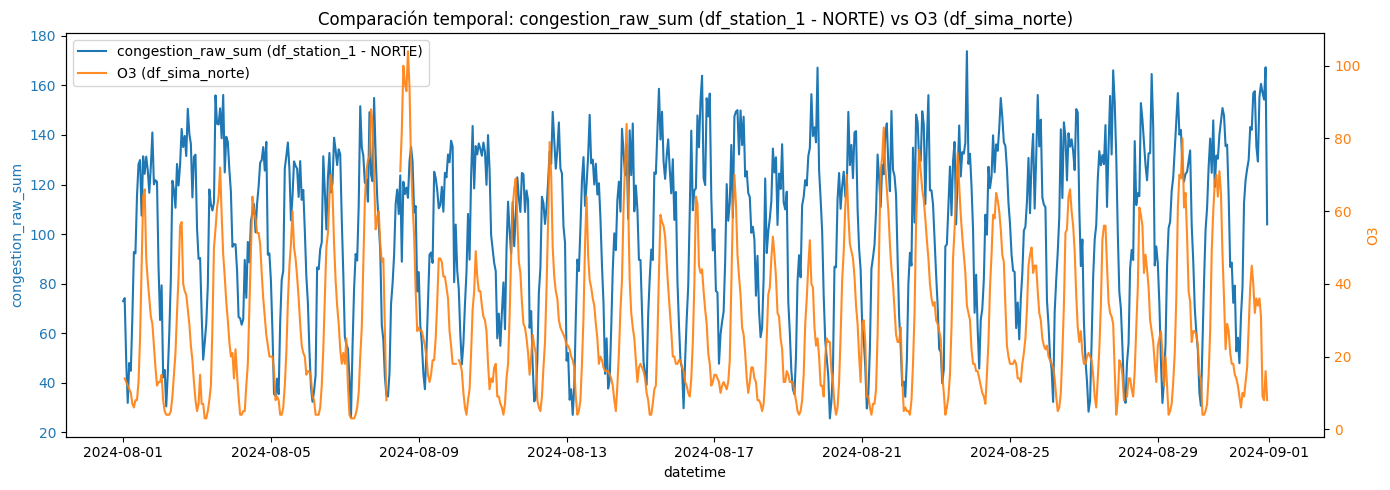

In [ ]:
# Convert df_station_1 (polars) to pandas and build a datetime column to match df_sima_norte
df_station_1_pd = df_station_1.to_pandas()
df_station_1_pd['date'] = pd.to_datetime(df_station_1_pd['date'])
df_station_1_pd['hour_start'] = df_station_1_pd['hour_start'].astype(int)
df_station_1_pd['datetime'] = df_station_1_pd['date'] + pd.to_timedelta(df_station_1_pd['hour_start'], unit='h')
df_station_1_pd = df_station_1_pd.sort_values('datetime')

# Ensure df_sima_norte date is datetime
df_sima_norte = df_sima_norte.copy()
df_sima_norte['date'] = pd.to_datetime(df_sima_norte['date'])

# Merge on the hourly datetime
merged = pd.merge(
    df_station_1_pd[['datetime', 'congestion_raw_sum']],
    df_sima_norte[['date', 'O3']],
    left_on='datetime',
    right_on='date',
    how='inner'
).sort_values('datetime')

# Plot with twin y-axis: congestion_raw_sum (left) and O3 (right)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(merged['datetime'], merged['congestion_raw_sum'], label='congestion_raw_sum (df_station_1 - NORTE)', color='tab:blue')
ax.set_xlabel('datetime')
ax.set_ylabel('congestion_raw_sum', color='tab:blue')
ax.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax.twinx()
ax2.plot(merged['datetime'], merged['O3'], label='O3 (df_sima_norte)', color='tab:orange', alpha=0.9)
ax2.set_ylabel('O3', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Combined legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title('Comparación temporal: congestion_raw_sum (df_station_1 - NORTE) vs O3 (df_sima_norte)')
plt.tight_layout()
plt.show()

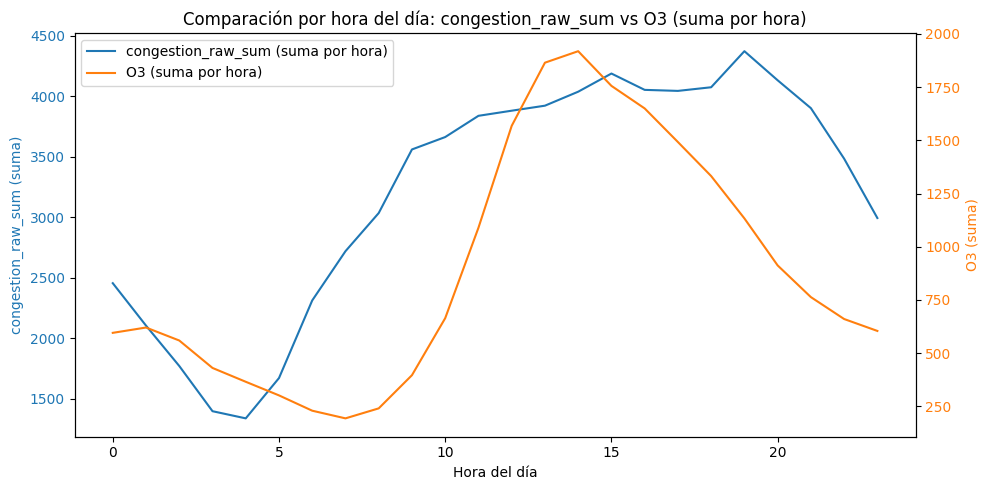

In [ ]:
# Agrupar por hora del día y calcular la suma para comparar congestion_raw_sum y O3 por hora
hourly = merged.copy()
hourly['hour'] = hourly['datetime'].dt.hour

# Sumar congestion_raw_sum y O3 por hora del día
hourly_sum = hourly.groupby('hour').agg({
    'congestion_raw_sum': 'sum',
    'O3': 'sum'
}).reset_index()

# Graficar la comparación por hora del día
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hourly_sum['hour'], hourly_sum['congestion_raw_sum'], label='congestion_raw_sum (suma por hora)', color='tab:blue')
ax.set_xlabel('Hora del día')
ax.set_ylabel('congestion_raw_sum (suma)', color='tab:blue')
ax.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax.twinx()
ax2.plot(hourly_sum['hour'], hourly_sum['O3'], label='O3 (suma por hora)', color='tab:orange')
ax2.set_ylabel('O3 (suma)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title('Comparación por hora del día: congestion_raw_sum vs O3 (suma por hora)')
plt.tight_layout()
plt.show()

In [ ]:
# Calcular la correlación de Pearson entre congestion_raw_sum y O3 (suma por hora)
correlacion = hourly_sum['congestion_raw_sum'].corr(hourly_sum['O3'])
print(f"Correlación Pearson entre congestion_raw_sum y O3 (suma por hora): {correlacion:.4f}")

Correlación Pearson entre congestion_raw_sum y O3 (suma por hora): 0.7179
